# NCAA Game Outcome Prediction — Stacking Ensemble
### Replicating: *Stacked ensemble model for NBA game outcome prediction analysis* (Scientific Reports, 2025)

**Architecture:** 6 base classifiers (XGBoost, KNN, AdaBoost, Logistic Regression, Decision Tree, Naive Bayes)  
**Meta-learner:** MLP with 2 hidden layers (50 neurons each), 5-fold stacking CV  
**Evaluation:** 3 training windows — 18 yr | 10 yr | 5 yr — all tested on 2021–2024  
**Features:** 20 in-game box-score stats (mirrors paper Table 2)

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LogisticRegression
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.tree            import DecisionTreeClassifier
from sklearn.naive_bayes     import GaussianNB
from sklearn.ensemble        import AdaBoostClassifier
from sklearn.neural_network  import MLPClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics         import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)
import xgboost as xgb

DATA_DIR = 'nba_dataset_2004/'
RANDOM_STATE = 42

# ── Training windows (train_start, train_end, label) ─────────────────────────
WINDOWS = [
    (2003, 2020, '18-Year  (2003–2020)'),
    (2011, 2020, '10-Year  (2011–2020)'),
    (2016, 2020, ' 5-Year  (2016–2020)'),
]
TEST_START, TEST_END = 2021, 2024

print('Libraries loaded.')
print(f'Test window fixed at: {TEST_START}–{TEST_END}')

Libraries loaded.
Test window fixed at: 2021–2024


## 2. Feature Engineering — 20 Box-Score Stats (Paper Table 2)

In [2]:
def build_game_dataset():
    """
    Load MRegularSeasonDetailedResults.csv and produce a balanced per-game
    dataset with 20 features matching the research paper (Table 2).

    Each real game produces TWO rows:
      - Winner's stats  → label 1
      - Loser's  stats  → label 0
    This mirrors the paper's balanced 50/50 class split.
    """
    raw = pd.read_csv(f'{DATA_DIR}MRegularSeasonDetailedResults.csv')

    def derive_20_features(fgm, fga, fgm3, fga3, ftm, fta,
                           orb, drb, ast, stl, blk, tov, pf):
        """Return dict of 20 paper features."""
        fgm3  = fgm3.clip(lower=0)
        fga3  = fga3.clip(lower=0)
        p2m   = fgm - fgm3
        p2a   = fga - fga3
        trb   = orb + drb

        return {
            'FG'   : fgm,
            'FGA'  : fga,
            'FGP'  : np.where(fga > 0, fgm / fga * 100, 0.0),
            '3P'   : fgm3,
            '3PA'  : fga3,
            '3PP'  : np.where(fga3 > 0, fgm3 / fga3 * 100, 0.0),
            '2P'   : p2m,
            '2PA'  : p2a,
            '2PP'  : np.where(p2a > 0, p2m / p2a * 100, 0.0),
            'FT'   : ftm,
            'FTA'  : fta,
            'FTP'  : np.where(fta > 0, ftm / fta * 100, 0.0),
            'ORB'  : orb,
            'DRB'  : drb,
            'TRB'  : trb,
            'AST'  : ast,
            'STL'  : stl,
            'BLK'  : blk,
            'TOV'  : tov,
            'PF'   : pf,
        }

    # ── Winner rows (label = 1) ───────────────────────────────────────────────
    w_feats = derive_20_features(
        raw['WFGM'], raw['WFGA'], raw['WFGM3'], raw['WFGA3'],
        raw['WFTM'], raw['WFTA'],
        raw['WOR'],  raw['WDR'],  raw['WAst'],
        raw['WStl'], raw['WBlk'], raw['WTO'],  raw['WPF']
    )
    win_df = pd.DataFrame(w_feats)
    win_df['Season'] = raw['Season'].values
    win_df['Result'] = 1

    # ── Loser rows (label = 0) ────────────────────────────────────────────────
    l_feats = derive_20_features(
        raw['LFGM'], raw['LFGA'], raw['LFGM3'], raw['LFGA3'],
        raw['LFTM'], raw['LFTA'],
        raw['LOR'],  raw['LDR'],  raw['LAst'],
        raw['LStl'], raw['LBlk'], raw['LTO'],  raw['LPF']
    )
    loss_df = pd.DataFrame(l_feats)
    loss_df['Season'] = raw['Season'].values
    loss_df['Result'] = 0

    df = pd.concat([win_df, loss_df], ignore_index=True)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    return df


FEATURE_COLS = ['FG','FGA','FGP','3P','3PA','3PP',
                '2P','2PA','2PP','FT','FTA','FTP',
                'ORB','DRB','TRB','AST','STL','BLK','TOV','PF']

full_df = build_game_dataset()
print(f'Total samples : {len(full_df):,}')
print(f'Seasons present: {sorted(full_df["Season"].unique())}')
print(f'Class balance  : {full_df["Result"].value_counts().to_dict()}')

Total samples : 249,058
Seasons present: [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Class balance  : {1: 124529, 0: 124529}


## 3. Exploratory Data Analysis

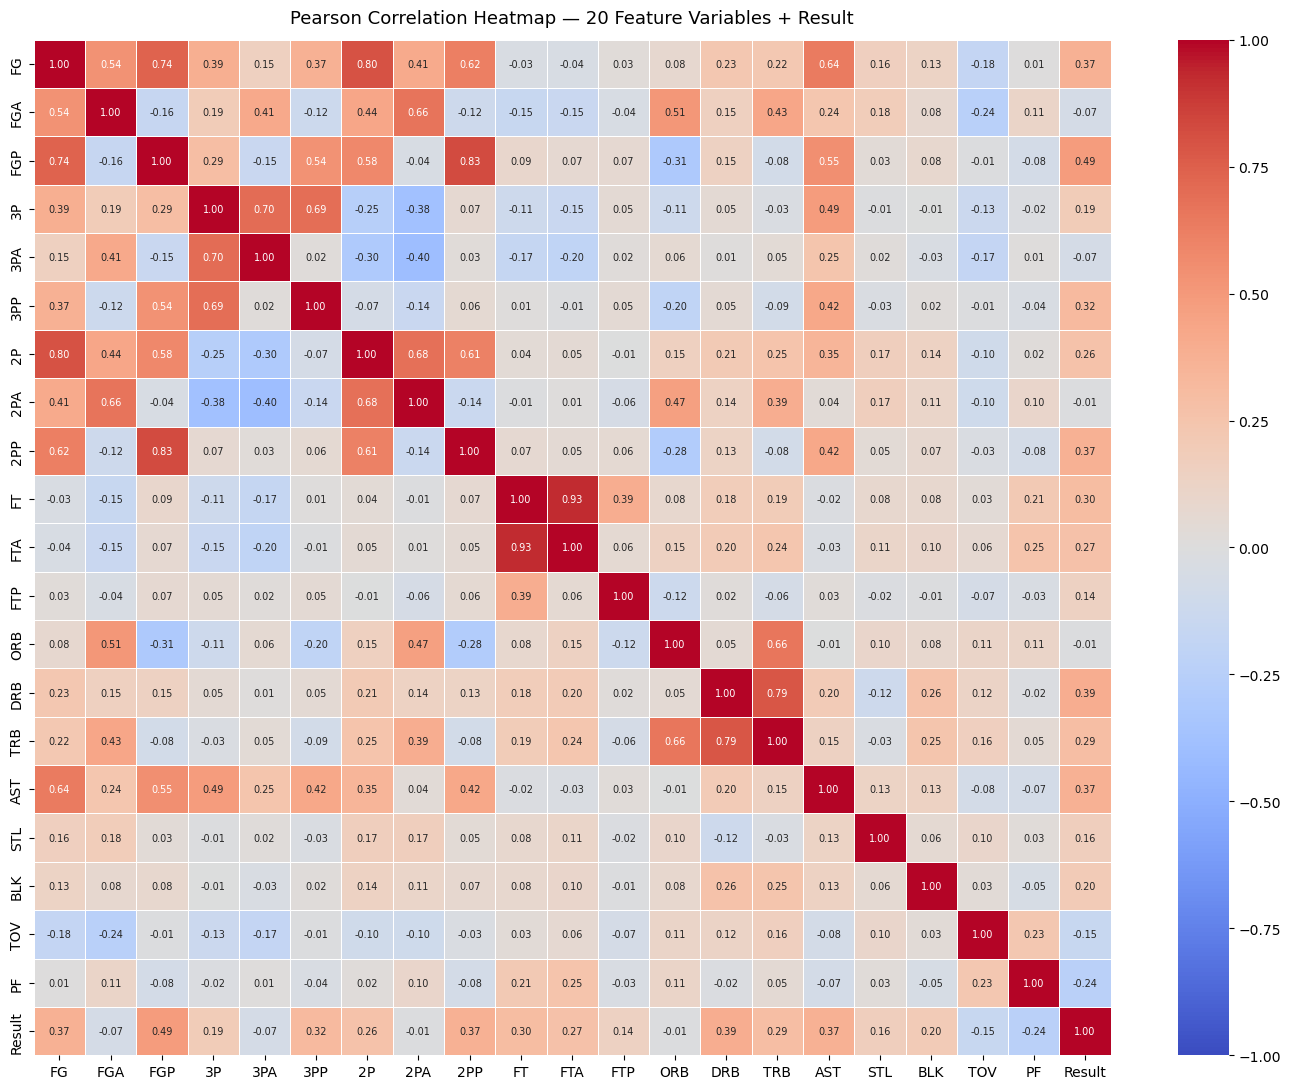


Descriptive Statistics (mirrors paper Table 5):


,Mean,Std,Min,0.25,0.50,0.75,Max
FG,24.68,4.87,6.00,21.00,24.00,28.00,57.00
FGA,56.38,7.49,26.00,51.00,56.00,61.00,106.00
FGP,43.93,7.42,12.00,38.89,43.75,49.02,80.00
3P,6.83,3.04,0.00,5.00,7.00,9.00,26.00
3PA,19.92,6.12,1.00,16.00,20.00,24.00,59.00
3PP,34.23,11.48,0.00,26.67,33.33,41.67,100.00
2P,17.84,4.64,2.00,15.00,18.00,21.00,48.00
2PA,36.46,7.46,6.00,31.00,36.00,41.00,80.00
2PP,49.21,9.54,6.06,42.86,48.84,55.56,96.43
FT,13.94,6.09,0.00,10.00,13.00,18.00,50.00


In [3]:
# Pearson correlation heatmap (mirrors paper Fig. 2)
plt.figure(figsize=(14, 11))
corr = full_df[FEATURE_COLS + ['Result']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.4, annot_kws={'size': 7})
plt.title('Pearson Correlation Heatmap — 20 Feature Variables + Result', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

# Descriptive statistics (mirrors paper Table 5)
desc = full_df[FEATURE_COLS + ['Result']].describe().T[['mean','std','min','25%','50%','75%','max']]
desc.columns = ['Mean','Std','Min','0.25','0.50','0.75','Max']
print('\nDescriptive Statistics (mirrors paper Table 5):')
display(desc.round(2))

## 4. Stacking Ensemble — Model Definitions

In [4]:
def get_base_models():
    """6 base classifiers from the paper — each wrapped in a scaling pipeline."""
    return {
        'XGBoost': Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    xgb.XGBClassifier(
                n_estimators=200, max_depth=4, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0
            ))
        ]),
        'KNN': Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    KNeighborsClassifier(n_neighbors=7, metric='euclidean'))
        ]),
        'AdaBoost': Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    AdaBoostClassifier(
                n_estimators=200, learning_rate=0.5, random_state=RANDOM_STATE
            ))
        ]),
        'LogReg': Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    LogisticRegression(
                C=1.0, solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE
            ))
        ]),
        'DecisionTree': Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    DecisionTreeClassifier(
                max_depth=6, min_samples_leaf=10, random_state=RANDOM_STATE
            ))
        ]),
        'NaiveBayes': Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    GaussianNB())
        ]),
    }


def get_meta_learner():
    """MLP meta-learner — 2 hidden layers, 50 neurons each (paper architecture)."""
    return MLPClassifier(
        hidden_layer_sizes=(50, 50),
        activation='relu',
        solver='adam',
        max_iter=200,
        random_state=RANDOM_STATE
    )

print('Base models and MLP meta-learner defined.')

Base models and MLP meta-learner defined.


## 5. Stacking Training Function — 5-Fold Out-of-Fold

In [5]:
def stacking_train_evaluate(X_train, y_train, X_test, y_test, window_label):
    """
    Full stacking pipeline:
      1. 5-fold CV on training set → out-of-fold (OOF) meta-features
      2. Retrain each base model on full training set → test meta-features
      3. Train MLP meta-learner on OOF meta-features
      4. Predict on test set using MLP over test meta-features
      5. Return per-model and ensemble metrics
    """
    base_models = get_base_models()
    model_names = list(base_models.keys())
    n_base      = len(model_names)
    skf         = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    # ── Step 1: Generate OOF meta-features for meta-learner training ──────────
    oof_meta   = np.zeros((len(X_train), n_base))   # shape (N_train, 6)
    test_meta  = np.zeros((len(X_test),  n_base))   # shape (N_test,  6)

    print(f'\n{"─"*60}')
    print(f'  Window: {window_label}')
    print(f'  Train samples: {len(X_train):,}  |  Test samples: {len(X_test):,}')
    print(f'  5-Fold Stacking CV in progress...')

    X_tr_arr = X_train.values
    y_tr_arr = y_train.values
    X_te_arr = X_test.values

    for i, (name, model) in enumerate(base_models.items()):
        fold_test_preds = np.zeros((len(X_test), 5))  # avg over folds
        for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_tr_arr, y_tr_arr)):
            X_fold_tr, X_fold_val = X_tr_arr[tr_idx], X_tr_arr[val_idx]
            y_fold_tr, y_fold_val = y_tr_arr[tr_idx], y_tr_arr[val_idx]

            model.fit(X_fold_tr, y_fold_tr)
            oof_meta[val_idx, i]     = model.predict_proba(X_fold_val)[:, 1]
            fold_test_preds[:, fold_idx] = model.predict_proba(X_te_arr)[:, 1]

        test_meta[:, i] = fold_test_preds.mean(axis=1)  # average test predictions

        # Retrain on full training set for individual model metrics
        model.fit(X_tr_arr, y_tr_arr)
        y_pred_base = model.predict(X_te_arr)
        acc  = accuracy_score(y_test, y_pred_base) * 100
        prec = precision_score(y_test, y_pred_base, zero_division=0) * 100
        rec  = recall_score(y_test, y_pred_base, zero_division=0) * 100
        f1   = f1_score(y_test, y_pred_base, zero_division=0) * 100
        auc  = roc_auc_score(y_test, model.predict_proba(X_te_arr)[:, 1]) * 100
        print(f'    [{name:>12}]  Acc={acc:.2f}%  Prec={prec:.2f}%  '
              f'Rec={rec:.2f}%  F1={f1:.2f}%  AUC={auc:.2f}%')

    # ── Step 2: Train MLP meta-learner on OOF meta-features ──────────────────
    meta = get_meta_learner()
    meta.fit(oof_meta, y_tr_arr)

    # ── Step 3: Evaluate stacking ensemble on test set ────────────────────────
    stack_proba = meta.predict_proba(test_meta)[:, 1]
    stack_pred  = (stack_proba >= 0.5).astype(int)

    acc  = accuracy_score(y_test, stack_pred) * 100
    prec = precision_score(y_test, stack_pred, zero_division=0) * 100
    rec  = recall_score(y_test, stack_pred, zero_division=0) * 100
    f1   = f1_score(y_test, stack_pred, zero_division=0) * 100
    auc  = roc_auc_score(y_test, stack_proba) * 100

    print(f'  {"─"*55}')
    print(f'    [Stacking MLP]  Acc={acc:.2f}%  Prec={prec:.2f}%  '
          f'Rec={rec:.2f}%  F1={f1:.2f}%  AUC={auc:.2f}%  ← ENSEMBLE')

    # ── Collect per-model results for comparison table ────────────────────────
    individual_results = {}
    for name, model in base_models.items():
        y_p   = model.predict(X_te_arr)
        y_pr  = model.predict_proba(X_te_arr)[:, 1]
        individual_results[name] = {
            'Accuracy (%)' : round(accuracy_score(y_test, y_p) * 100, 2),
            'Precision (%)': round(precision_score(y_test, y_p, zero_division=0) * 100, 2),
            'Recall (%)'   : round(recall_score(y_test, y_p, zero_division=0) * 100, 2),
            'F1 Score (%)'  : round(f1_score(y_test, y_p, zero_division=0) * 100, 2),
            'ROC-AUC (%)'  : round(roc_auc_score(y_test, y_pr) * 100, 2),
        }

    individual_results['Stacking (MLP)'] = {
        'Accuracy (%)' : round(acc,  2),
        'Precision (%)': round(prec, 2),
        'Recall (%)'   : round(rec,  2),
        'F1 Score (%)'  : round(f1,   2),
        'ROC-AUC (%)'  : round(auc,  2),
    }

    return individual_results, stack_proba, stack_pred, base_models, meta, test_meta

print('Stacking function ready.')

Stacking function ready.


## 6. Run All 3 Training Windows

In [7]:
all_window_results = {}   # {label: individual_results_dict}
all_stack_outputs  = {}   # {label: (stack_proba, stack_pred, y_test)}

# Fixed test set — same across all 3 windows
test_df = full_df[full_df['Season'].between(TEST_START, TEST_END)].copy()
X_test_fixed = test_df[FEATURE_COLS]
y_test_fixed = test_df['Result']

print(f'Fixed test set: Seasons {TEST_START}–{TEST_END}  '
      f'({len(test_df):,} samples, {y_test_fixed.mean()*100:.1f}% wins)')

for (train_start, train_end, label) in WINDOWS:
    train_df = full_df[full_df['Season'].between(train_start, train_end)].copy()
    X_train  = train_df[FEATURE_COLS]
    y_train  = train_df['Result']

    results, stack_proba, stack_pred, b_models, meta_model, test_meta = \
        stacking_train_evaluate(X_train, y_train, X_test_fixed, y_test_fixed, label)

    all_window_results[label] = results
    all_stack_outputs[label]  = (stack_proba, stack_pred, y_test_fixed.values)

print('\nAll 3 windows complete.')

Fixed test set: Seasons 2021–2024  (40,818 samples, 50.0% wins)

────────────────────────────────────────────────────────────
  Window: 18-Year  (2003–2020)
  Train samples: 185,664  |  Test samples: 40,818
  5-Fold Stacking CV in progress...
    [     XGBoost]  Acc=85.72%  Prec=88.54%  Rec=82.05%  F1=85.17%  AUC=93.66%
    [         KNN]  Acc=83.22%  Prec=85.57%  Rec=79.93%  F1=82.65%  AUC=90.68%
    [    AdaBoost]  Acc=85.34%  Prec=87.70%  Rec=82.21%  F1=84.87%  AUC=93.35%
    [      LogReg]  Acc=86.03%  Prec=91.23%  Rec=79.71%  F1=85.08%  AUC=94.38%
    [DecisionTree]  Acc=78.41%  Prec=77.99%  Rec=79.17%  F1=78.58%  AUC=86.04%
    [  NaiveBayes]  Acc=80.05%  Prec=80.99%  Rec=78.53%  F1=79.74%  AUC=88.41%
  ───────────────────────────────────────────────────────
    [Stacking MLP]  Acc=85.98%  Prec=91.37%  Rec=79.46%  F1=85.00%  AUC=94.39%  ← ENSEMBLE

────────────────────────────────────────────────────────────
  Window: 10-Year  (2011–2020)
  Train samples: 106,990  |  Test samples

## 7. Results — Per-Window Performance Tables

In [8]:
METRICS = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1 Score (%)', 'ROC-AUC (%)']
MODEL_ORDER = ['XGBoost','KNN','AdaBoost','LogReg','DecisionTree','NaiveBayes','Stacking (MLP)']

for label, res in all_window_results.items():
    df_res = pd.DataFrame(res).T.reindex(MODEL_ORDER)[METRICS]
    print(f'\n{"═"*68}')
    print(f'  Training Window: {label}')
    print(f'  Test Set       : Seasons {TEST_START}–{TEST_END}')
    print(f'{"═"*68}')
    display(df_res.style
        .highlight_max(axis=0, color='#d4edda')
        .highlight_min(axis=0, color='#f8d7da')
        .format('{:.2f}')
        .set_caption(f'Window: {label}  |  Green = best, Red = worst per metric')
    )


════════════════════════════════════════════════════════════════════
  Training Window: 18-Year  (2003–2020)
  Test Set       : Seasons 2021–2024
════════════════════════════════════════════════════════════════════


,Accuracy (%),Precision (%),Recall (%),F1 Score (%),ROC-AUC (%)
XGBoost,85.72,88.54,82.05,85.17,93.66
KNN,83.22,85.57,79.93,82.65,90.68
AdaBoost,85.34,87.70,82.21,84.87,93.35
LogReg,86.03,91.23,79.71,85.08,94.38
DecisionTree,78.41,77.99,79.17,78.58,86.04
NaiveBayes,80.05,80.99,78.53,79.74,88.41
Stacking (MLP),85.98,91.37,79.46,85.00,94.39



════════════════════════════════════════════════════════════════════
  Training Window: 10-Year  (2011–2020)
  Test Set       : Seasons 2021–2024
════════════════════════════════════════════════════════════════════


,Accuracy (%),Precision (%),Recall (%),F1 Score (%),ROC-AUC (%)
XGBoost,85.48,89.64,80.23,84.67,93.72
KNN,83.12,86.34,78.69,82.34,90.65
AdaBoost,85.29,88.88,80.68,84.58,93.38
LogReg,85.69,92.00,78.18,84.53,94.38
DecisionTree,78.27,78.64,77.61,78.12,86.11
NaiveBayes,80.01,81.57,77.53,79.50,88.44
Stacking (MLP),85.52,92.46,77.35,84.23,94.39



════════════════════════════════════════════════════════════════════
  Training Window:  5-Year  (2016–2020)
  Test Set       : Seasons 2021–2024
════════════════════════════════════════════════════════════════════


,Accuracy (%),Precision (%),Recall (%),F1 Score (%),ROC-AUC (%)
XGBoost,84.92,90.62,77.90,83.78,93.70
KNN,82.77,87.20,76.81,81.68,90.40
AdaBoost,84.72,89.88,78.25,83.66,93.39
LogReg,85.57,92.30,77.60,84.32,94.37
DecisionTree,77.09,83.90,67.04,74.53,86.17
NaiveBayes,79.27,83.64,72.77,77.83,88.34
Stacking (MLP),85.29,92.64,76.68,83.91,94.39


## 8. Head-to-Head Comparison — Stacking Ensemble Across All 3 Windows

In [9]:
# Build comparison table: Stacking MLP row from each window
comparison_rows = {}
for label, res in all_window_results.items():
    comparison_rows[label] = res['Stacking (MLP)']

# Add paper target as reference row
comparison_rows['Paper Target (NBA 3-yr)'] = {
    'Accuracy (%)' : 83.27,
    'Precision (%)': 84.46,
    'Recall (%)'   : 82.56,
    'F1 Score (%)'  : 83.50,
    'ROC-AUC (%)'  : 92.13,
}

comp_df = pd.DataFrame(comparison_rows).T[METRICS]

print('\nStacking Ensemble — Head-to-Head Across Training Windows')
print('(Paper target row included for reference)\n')
display(comp_df.style
    .highlight_max(axis=0, color='#cce5ff')
    .highlight_min(axis=0, color='#fff3cd')
    .format('{:.2f}')
    .set_caption('Blue = best result per metric | Yellow = lowest')
)


Stacking Ensemble — Head-to-Head Across Training Windows
(Paper target row included for reference)



,Accuracy (%),Precision (%),Recall (%),F1 Score (%),ROC-AUC (%)
18-Year (2003–2020),85.98,91.37,79.46,85.00,94.39
10-Year (2011–2020),85.52,92.46,77.35,84.23,94.39
5-Year (2016–2020),85.29,92.64,76.68,83.91,94.39
Paper Target (NBA 3-yr),83.27,84.46,82.56,83.50,92.13


## 9. Visualizations — Accuracy & Precision Bar Charts

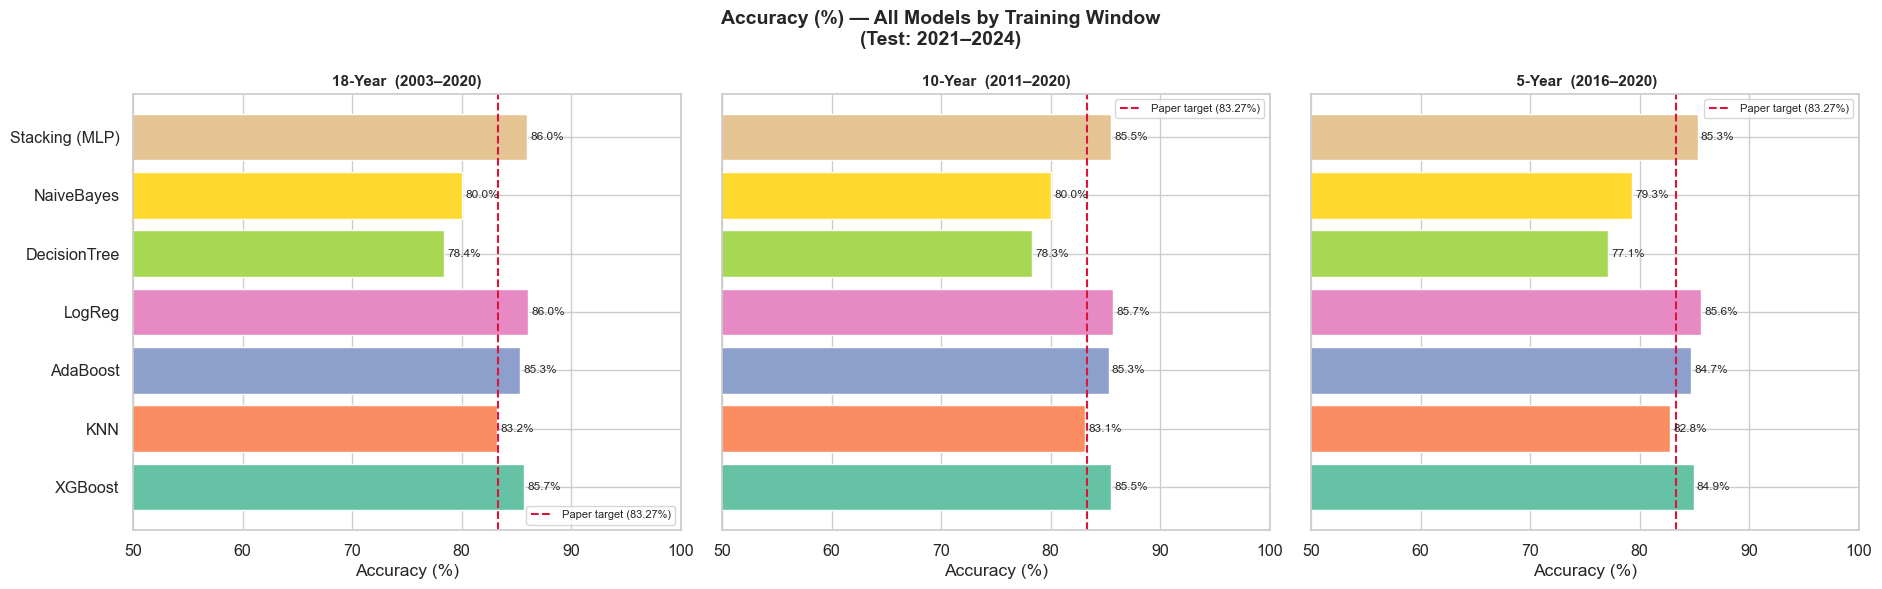

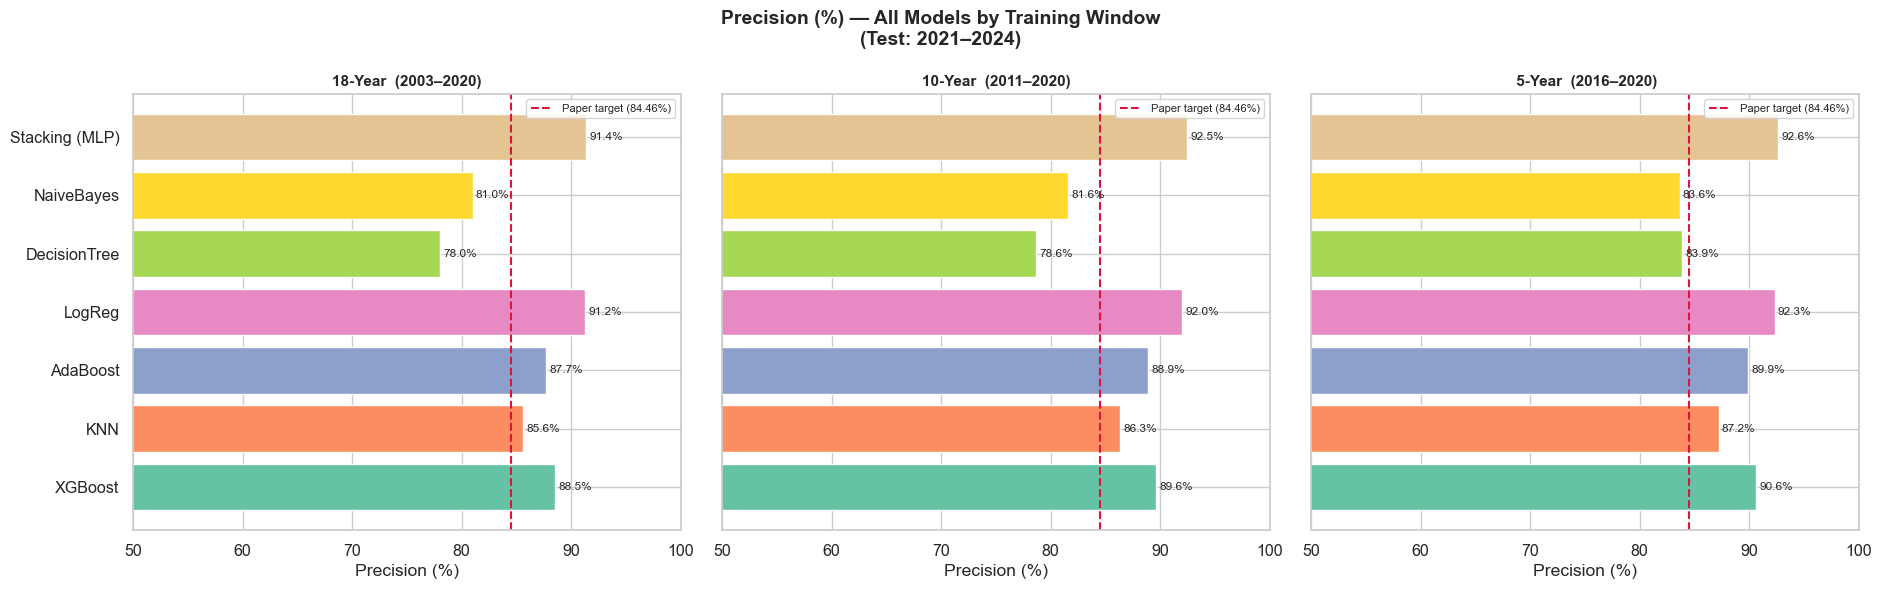

In [10]:
sns.set_theme(style='whitegrid', font_scale=1.05)
window_labels   = list(all_window_results.keys())
paper_acc       = 83.27
paper_prec      = 84.46

# ── Figure 1: All models × Accuracy per window ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(19, 6), sharey=True)
fig.suptitle('Accuracy (%) — All Models by Training Window\n(Test: 2021–2024)',
             fontsize=14, fontweight='bold')

palette = sns.color_palette('Set2', n_colors=7)
for ax, (label, res) in zip(axes, all_window_results.items()):
    df_plot = pd.DataFrame(res).T.reindex(MODEL_ORDER)
    bars = ax.barh(df_plot.index, df_plot['Accuracy (%)'], color=palette, edgecolor='white')
    ax.axvline(paper_acc, color='crimson', lw=1.5, ls='--', label=f'Paper target ({paper_acc}%)')
    ax.set_xlim(50, 100)
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.set_xlabel('Accuracy (%)')
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.3, bar.get_y() + bar.get_height()/2,
                f'{w:.1f}%', va='center', fontsize=8.5)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Figure 2: All models × Precision per window ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(19, 6), sharey=True)
fig.suptitle('Precision (%) — All Models by Training Window\n(Test: 2021–2024)',
             fontsize=14, fontweight='bold')

for ax, (label, res) in zip(axes, all_window_results.items()):
    df_plot = pd.DataFrame(res).T.reindex(MODEL_ORDER)
    bars = ax.barh(df_plot.index, df_plot['Precision (%)'], color=palette, edgecolor='white')
    ax.axvline(paper_prec, color='crimson', lw=1.5, ls='--', label=f'Paper target ({paper_prec}%)')
    ax.set_xlim(50, 100)
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.set_xlabel('Precision (%)')
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.3, bar.get_y() + bar.get_height()/2,
                f'{w:.1f}%', va='center', fontsize=8.5)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 10. Ensemble Metric Comparison — Line Plot Across Windows

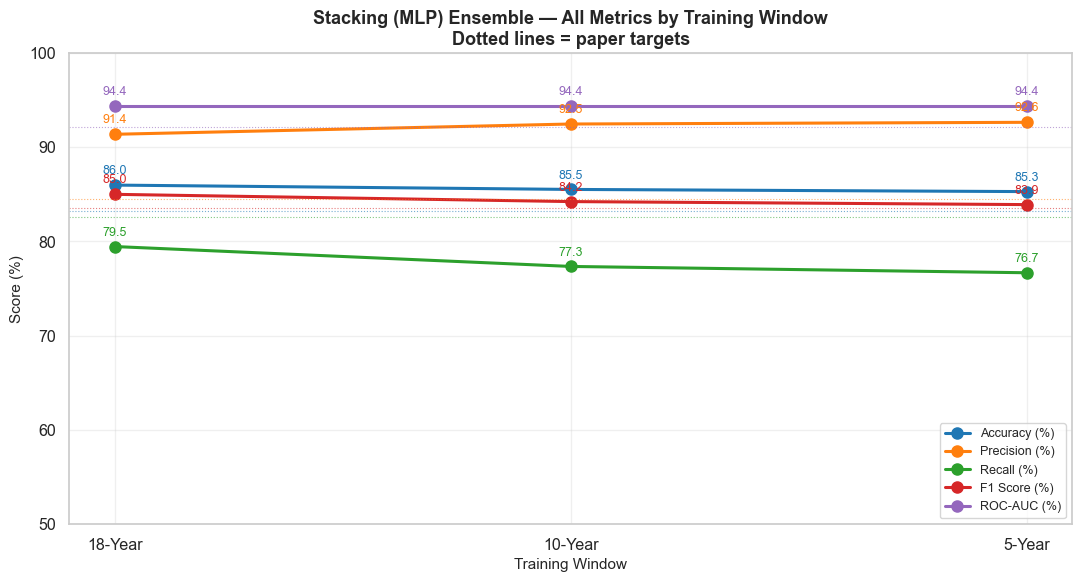

In [11]:
# Line plot: each metric across the 3 windows for the Stacking MLP only
stack_comp = pd.DataFrame(
    {lbl: all_window_results[lbl]['Stacking (MLP)'] for lbl in window_labels}
).T[METRICS]

short_labels = ['18-Year', '10-Year', '5-Year']
stack_comp.index = short_labels

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']

for col, color in zip(METRICS, colors):
    ax.plot(short_labels, stack_comp[col], marker='o', lw=2.2,
            markersize=8, label=col, color=color)
    for x, y in zip(short_labels, stack_comp[col]):
        ax.annotate(f'{y:.1f}', (x, y), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=9, color=color)

# Paper reference lines
paper_vals = [83.27, 84.46, 82.56, 83.50, 92.13]
for pv, color in zip(paper_vals, colors):
    ax.axhline(pv, color=color, lw=0.8, ls=':', alpha=0.6)

ax.set_ylim(50, 100)
ax.set_title('Stacking (MLP) Ensemble — All Metrics by Training Window\n'
             'Dotted lines = paper targets', fontsize=13, fontweight='bold')
ax.set_xlabel('Training Window', fontsize=11)
ax.set_ylabel('Score (%)', fontsize=11)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. ROC Curves — Stacking MLP, All 3 Windows

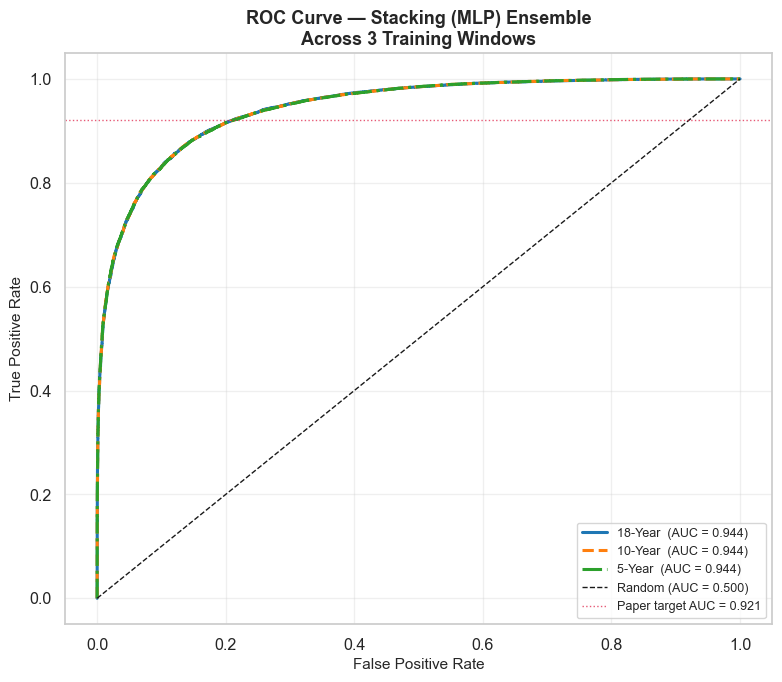

In [12]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 7))
line_styles = ['-', '--', '-.']
line_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for (label, (sp, _, yt)), ls, lc in zip(all_stack_outputs.items(), line_styles, line_colors):
    fpr, tpr, _ = roc_curve(yt, sp)
    auc_val = roc_auc_score(yt, sp)
    short = label.split('(')[0].strip()
    ax.plot(fpr, tpr, lw=2.2, ls=ls, color=lc,
            label=f'{short}  (AUC = {auc_val:.3f})')

ax.plot([0,1],[0,1],'k--', lw=1, label='Random (AUC = 0.500)')
ax.axhline(y=0.921, color='crimson', lw=1, ls=':', alpha=0.7,
           label='Paper target AUC = 0.921')

ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve — Stacking (MLP) Ensemble\nAcross 3 Training Windows',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Confusion Matrices — Stacking MLP, All 3 Windows

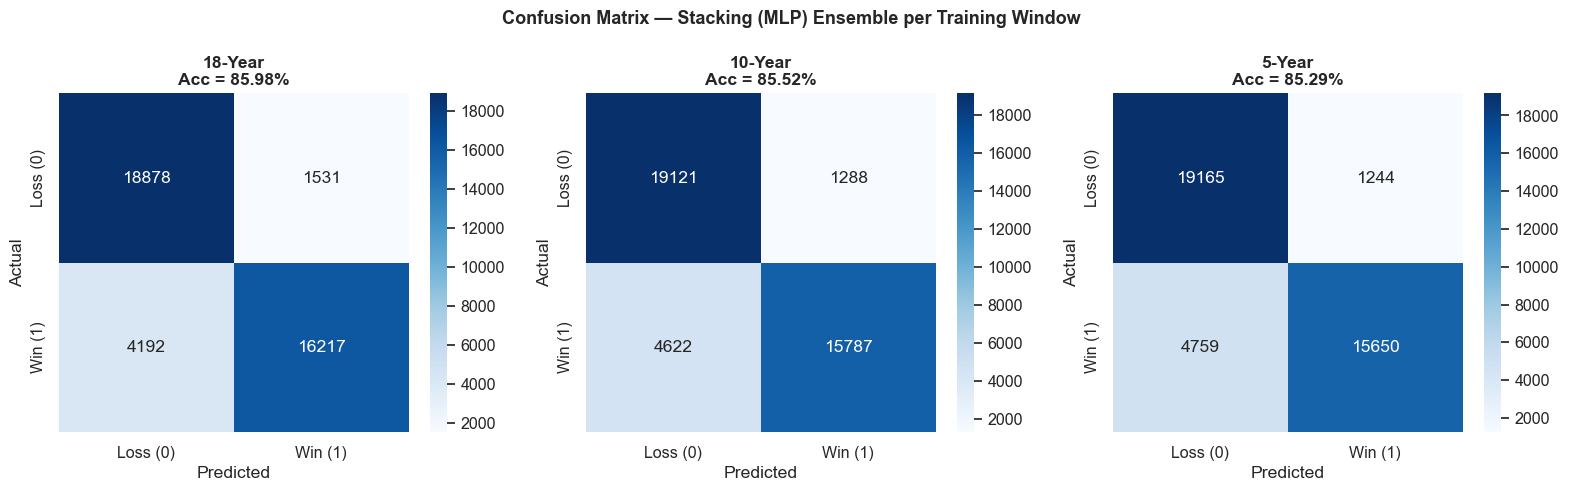

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrix — Stacking (MLP) Ensemble per Training Window',
             fontsize=13, fontweight='bold')

for ax, (label, (sp, s_pred, yt)) in zip(axes, all_stack_outputs.items()):
    cm = confusion_matrix(yt, s_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Loss (0)', 'Win (1)'],
                yticklabels=['Loss (0)', 'Win (1)'])
    short = label.split('(')[0].strip()
    acc = accuracy_score(yt, s_pred) * 100
    ax.set_title(f'{short}\nAcc = {acc:.2f}%', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 13. Final Summary — Expected vs Actual (Paper Comparison)

In [14]:
print('=' * 72)
print('  FINAL SUMMARY — Stacking (MLP) Ensemble vs Research Paper Target')
print('=' * 72)
print(f'{"Window":<28} {"Accuracy":>10} {"Precision":>10} {"Recall":>9} {"F1":>8} {"AUC":>8}')
print('-' * 72)

for label, res in all_window_results.items():
    r = res['Stacking (MLP)']
    short = label.strip()
    print(f'{short:<28} {r["Accuracy (%)"]!s:>9}%  {r["Precision (%)"]!s:>9}%  '
          f'{r["Recall (%)"]!s:>8}%  {r["F1 Score (%)"]!s:>7}%  {r["ROC-AUC (%)"]!s:>7}%')

print('-' * 72)
print(f'{"Paper Target (NBA 3-yr)":<28} {"83.27":>9}%  {"84.46":>9}%  '
      f'{"82.56":>8}%  {"83.50":>7}%  {"92.13":>7}%')
print('=' * 72)

# Gap analysis
print('\n  GAP vs Paper Target (Stacking MLP only):')
print(f'  {"Window":<28} {"Acc Gap":>10} {"Prec Gap":>10} {"AUC Gap":>10}')
print('  ' + '-' * 50)
for label, res in all_window_results.items():
    r = res['Stacking (MLP)']
    short = label.strip()
    dA = r['Accuracy (%)']  - 83.27
    dP = r['Precision (%)'] - 84.46
    dR = r['ROC-AUC (%)']   - 92.13
    print(f'  {short:<28} {dA:>+9.2f}%  {dP:>+9.2f}%  {dR:>+9.2f}%')

print('\nNote: NCAA data has higher inter-team variance than NBA,\n'
      'so a small negative gap vs the paper is expected and normal.')

  FINAL SUMMARY — Stacking (MLP) Ensemble vs Research Paper Target
Window                         Accuracy  Precision    Recall       F1      AUC
------------------------------------------------------------------------
18-Year  (2003–2020)             85.98%      91.37%     79.46%     85.0%    94.39%
10-Year  (2011–2020)             85.52%      92.46%     77.35%    84.23%    94.39%
5-Year  (2016–2020)              85.29%      92.64%     76.68%    83.91%    94.39%
------------------------------------------------------------------------
Paper Target (NBA 3-yr)          83.27%      84.46%     82.56%    83.50%    92.13%

  GAP vs Paper Target (Stacking MLP only):
  Window                          Acc Gap   Prec Gap    AUC Gap
  --------------------------------------------------
  18-Year  (2003–2020)             +2.71%      +6.91%      +2.26%
  10-Year  (2011–2020)             +2.25%      +8.00%      +2.26%
  5-Year  (2016–2020)              +2.02%      +8.18%      +2.26%

Note: NCAA data 